# Connect Four: Comparing PPO Variants with PettingZoo

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/deijany/RL-connecting-four/blob/main/connect_four_ppo.ipynb)

This notebook trains and compares three policy-gradient agents on **Connect Four** (`connect_four_v3`),
a two-player zero-sum game from [PettingZoo Classic](https://pettingzoo.farama.org/environments/classic/).

## The Game

Connect Four is a 6×7 grid game. Two players alternate placing pieces; the first to align
four pieces horizontally, vertically, or diagonally wins. The state space is small enough
for fast training, yet non-trivial enough to distinguish good and bad policies.

## PettingZoo AEC API

PettingZoo exposes multi-agent environments through the **Agent Environment Cycle (AEC)** interface:

- `env.agent_iter()` - cycles through agents whose turn it is
- `env.last()` - returns `(obs, reward, terminated, truncated, info)` for the current agent
- `env.step(action)` - advances the environment one step

The observation for each agent is a **dict**: `{"observation": array, "action_mask": array}`.  
The `action_mask` is a binary vector of length 7 (one per column); `1` = legal, `0` = illegal (column full).

## Why Action Masking Matters

Without masking, a learned policy may waste capacity on illegal moves and produce numerically
unstable gradients. `sb3_contrib.MaskablePPO` zeroes illegal-action logits *before* the softmax,
so the policy is never rewarded for selecting them.

## PPO Objective

All three variants optimise a clipped surrogate objective. Let
$r_t(\theta) = \pi_\theta(a_t|s_t) / \pi_{\theta_{\text{old}}}(a_t|s_t)$ be the probability ratio
and $\hat{A}_t$ the advantage estimate:

$$L^{\text{CLIP}}(\theta) = \mathbb{E}_t\!\left[\min\!\left(r_t(\theta)\,\hat{A}_t,\;
\mathrm{clip}(r_t(\theta),\,1-\varepsilon,\,1+\varepsilon)\,\hat{A}_t\right)\right]$$

The clip prevents large policy updates that destabilise training.

In [8]:
import sys
import subprocess

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    subprocess.run(
        ["git", "clone", "-q", "https://github.com/deijany/RL-connecting-four.git", "repo"],
        check=True,
    )
    sys.path.insert(0, "repo")
    %pip install -q "pettingzoo==1.26.1" "pygame-ce==2.5.7" "stable-baselines3==2.8.0" "sb3-contrib==2.8.0"
    %pip install -q --no-deps "gymnasium==0.29.1"

In [9]:
%matplotlib inline
import sys
import os
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt

# Repo root on path so 'import src' works when the notebook is in connect_four/
sys.path.insert(0, os.path.abspath("."))

from pettingzoo.classic import connect_four_v3
from src import (
    train_masked,
    train_vanilla,
    train_custom,
    evaluate_vs_random,
    evaluate_vanilla_vs_random,
    evaluate_custom_vs_random,
    plot_winrates,
    plot_training_curves,
)
print("Setup complete.")

Setup complete.


In [10]:
# Parameters 
SEED        = 1
MODELS_DIR  = "models"

# Training budget
TOTAL_STEPS = 1_000_000  
EVAL_EVERY_TRAIN_TRAIN = 100_000  # print win-rate stats every N training steps (None to disable)

# Parallelism -- independent cores collecting experience simultaneously
N_CORES = min(10, os.cpu_count())

# Rollout (one collect phase before each update)
N_STEPS     = 256        # min steps per worker before triggering an update
N_EPOCHS    = 5          # passes over each rollout before discarding
MINIBATCH_SIZE = 64      

# Optimisation
LR          = 3e-4      
GAMMA       = 0.99       # discount factor
CLIP_RANGE  = 0.2        # PPO clip epsilon
GAE_LAMBDA  = 0.95       # GAE bias/variance tradeoff
ENT_COEF    = 0.01       # entropy bonus weight (exploration)
VF_COEF     = 1.0        # value loss weight
TARGET_KL   = 0.01       # KL early-stopping threshold for custom PPO (None to disable)

# Evaluation
EVAL_GAMES  = 10_000
COLORS = {
    "Masked PPO":  "steelblue",
    "Vanilla PPO": "darkorange",
    "Custom PPO":  "darkgreen",
    "win":         "steelblue",
    "loss":        "red",
    "tie":         "gray",
}

os.makedirs(MODELS_DIR, exist_ok=True)
print(f"seed={SEED}  |  total_steps={TOTAL_STEPS}  |  n_cores={N_CORES}  |  "
      f"n_steps={N_STEPS}  |  n_epochs={N_EPOCHS}  |  minibatch_size={MINIBATCH_SIZE}  |  "
      f"target_kl={TARGET_KL}  |  eval={EVAL_GAMES} games")

seed=1  |  total_steps=1000000  |  n_cores=10  |  n_steps=256  |  n_epochs=5  |  minibatch_size=64  |  target_kl=0.01  |  eval=10000 games


## Section I -- Masked PPO (`MaskablePPO`)

`sb3_contrib.MaskablePPO` is the canonical baseline for action-masked environments.
It wraps the observation with a legal-move mask and zeroes the logits of illegal actions
before the softmax. Since the mask is applied *inside* the policy, the policy gradient
signal is always over legal moves only.

**Self-play:** both agents share the same network. `SB3ActionMaskWrapper` bridges the
PettingZoo AEC interface to Stable-Baselines3's single-agent API, alternating which seat
the network controls each step.

> Increase `TOTAL_STEPS` in the Parameters cell above for stronger training.

In [11]:
print("Training Masked PPO ...")
masked_path, masked_steps, masked_losses = train_masked(
    connect_four_v3, steps=TOTAL_STEPS, seed=SEED, save_dir=MODELS_DIR,
    return_losses=True,
    n_steps=N_STEPS, n_epochs=N_EPOCHS, minibatch_size=MINIBATCH_SIZE, lr=LR, gamma=GAMMA,
    clip_range=CLIP_RANGE, gae_lambda=GAE_LAMBDA, ent_coef=ENT_COEF, vf_coef=VF_COEF,
    n_cores=N_CORES,
    eval_every=EVAL_EVERY_TRAIN_TRAIN, eval_games=500,
)
print(f"Saved: {masked_path}  ({len(masked_losses)} updates over {masked_steps[-1] if masked_steps else 0} steps)")

Training Masked PPO ...
  [Masked PPO] step  100,000 | win  88.4%  loss  11.6%  tie  0.0%  (500 games)
  [Masked PPO] step  200,000 | win  86.4%  loss  13.6%  tie  0.0%  (500 games)
  [Masked PPO] step  300,000 | win  86.6%  loss  13.4%  tie  0.0%  (500 games)
  [Masked PPO] step  400,000 | win  88.8%  loss  11.2%  tie  0.0%  (500 games)
  [Masked PPO] step  500,000 | win  86.0%  loss  14.0%  tie  0.0%  (500 games)
  [Masked PPO] step  600,000 | win  87.8%  loss  12.2%  tie  0.0%  (500 games)
  [Masked PPO] step  700,000 | win  90.2%  loss   9.8%  tie  0.0%  (500 games)
  [Masked PPO] step  800,000 | win  87.2%  loss  12.8%  tie  0.0%  (500 games)
  [Masked PPO] step  900,000 | win  86.0%  loss  14.0%  tie  0.0%  (500 games)
  [Masked PPO] step 1,000,000 | win  86.0%  loss  14.0%  tie  0.0%  (500 games)
Saved: models/env_20260829-025039.zip  (4000 updates over 1000000 steps)


## Section II -- Vanilla PPO (SB3 PPO, no training mask)

A standard `stable_baselines3.PPO` is trained on a Gym-adapted wrapper (`PettingZooToGymEnv`).
There is **no action masking during training** - the policy can select any column, even a full one.
At evaluation time the mask is reapplied: if the predicted action is illegal, a random legal
action is chosen instead.

**Expected behaviour:** vanilla PPO learns more slowly and may never match the masked variant,
because gradients are computed over a noisy distribution that includes illegal moves.

> Increase `TOTAL_STEPS` in the Parameters cell above for stronger training.

In [12]:
print("Training Vanilla PPO ...")
vanilla_path, vanilla_steps, vanilla_losses = train_vanilla(
    connect_four_v3, steps=TOTAL_STEPS, seed=SEED, save_dir=MODELS_DIR,
    return_losses=True,
    n_steps=N_STEPS, n_epochs=N_EPOCHS, minibatch_size=MINIBATCH_SIZE, lr=LR, gamma=GAMMA,
    clip_range=CLIP_RANGE, gae_lambda=GAE_LAMBDA, ent_coef=ENT_COEF, vf_coef=VF_COEF,
    n_cores=N_CORES,
    eval_every=EVAL_EVERY_TRAIN_TRAIN, eval_games=500,
)
print(f"Saved: {vanilla_path}  ({len(vanilla_losses)} updates over {vanilla_steps[-1] if vanilla_steps else 0} steps)")

Training Vanilla PPO ...
[WARNING]: Illegal move made, game terminating with current player losing. 
obs['action_mask'] contains a mask of all legal moves that can be chosen.
[WARNING]: Illegal move made, game terminating with current player losing. 
obs['action_mask'] contains a mask of all legal moves that can be chosen.
[WARNING]: Illegal move made, game terminating with current player losing. 
obs['action_mask'] contains a mask of all legal moves that can be chosen.
[WARNING]: Illegal move made, game terminating with current player losing. 
obs['action_mask'] contains a mask of all legal moves that can be chosen.
[WARNING]: Illegal move made, game terminating with current player losing. 
obs['action_mask'] contains a mask of all legal moves that can be chosen.
[WARNING]: Illegal move made, game terminating with current player losing. 
obs['action_mask'] contains a mask of all legal moves that can be chosen.
[WARNING]: Illegal move made, game terminating with current player losing. 

## Section III -- Custom PPO (pure PyTorch, manual masking)

Trained with a hand-written PPO loop instead of Stable-Baselines3. Illegal logits get set to `-inf` before the softmax, so training only ever sees legal moves, same idea as masked PPO but done by hand.

Trajectories come from `N_CORES` worker subprocesses (`ParallelAECCollector`). The difference from the SB3 rollouts above: each worker plays out full games rather than stopping at a fixed step count, so no episode is ever cut mid-way.

**Expected behaviour:** should track masked PPO fairly closely -- both mask illegal moves during training.

> Increase `TOTAL_STEPS` in the Parameters cell above for stronger training.

In [13]:
print("Training Custom PPO ...")
custom_ppo, custom_steps, custom_losses = train_custom(
    connect_four_v3, steps=TOTAL_STEPS, seed=SEED,
    n_steps=N_STEPS, n_epochs=N_EPOCHS, minibatch_size=MINIBATCH_SIZE, lr=LR, gamma=GAMMA,
    clip_range=CLIP_RANGE, gae_lambda=GAE_LAMBDA, ent_coef=ENT_COEF, vf_coef=VF_COEF,
    n_cores=N_CORES,
    target_kl=TARGET_KL,
    eval_every=EVAL_EVERY_TRAIN_TRAIN, eval_games=500,
)
print(f"Training complete. {len(custom_losses)} updates over {custom_steps[-1] if custom_steps else 0} steps")

Training Custom PPO ...
  [Custom PPO] step  100,255 | win  91.8%  loss   8.2%  tie  0.0%  (500 games)
  [Custom PPO] step  200,074 | win  92.4%  loss   7.6%  tie  0.0%  (500 games)
  [Custom PPO] step  300,099 | win  91.2%  loss   8.8%  tie  0.0%  (500 games)
  [Custom PPO] step  400,295 | win  91.2%  loss   8.8%  tie  0.0%  (500 games)
  [Custom PPO] step  500,006 | win  88.4%  loss  11.6%  tie  0.0%  (500 games)
  [Custom PPO] step  600,140 | win  88.8%  loss  11.2%  tie  0.0%  (500 games)
  [Custom PPO] step  700,289 | win  91.8%  loss   8.2%  tie  0.0%  (500 games)
  [Custom PPO] step  800,172 | win  91.6%  loss   8.4%  tie  0.0%  (500 games)
  [Custom PPO] step  900,015 | win  90.4%  loss   9.6%  tie  0.0%  (500 games)
  [Custom PPO] step 1,000,060 | win  89.8%  loss  10.2%  tie  0.0%  (500 games)
Training complete. 3126 updates over 1000060 steps


## Comparison -- Win Rates and Training Curves

All three variants are evaluated against a random opponent for `EVAL_GAMES` games each.
The masked variant uses its native `action_masks` interface; the vanilla model falls back to
a random legal move when its prediction is illegal; the custom model applies the mask directly
to the action probabilities before greedy selection.


Evaluating Masked PPO vs random ...
  Masked PPO  -- {'win': 8644, 'loss': 1356, 'tie': 0}
Evaluating Vanilla PPO vs random ...
  Vanilla PPO -- {'win': 8444, 'loss': 1554, 'tie': 2}
Evaluating Custom PPO vs random ...
  Custom PPO  -- {'win': 9093, 'loss': 907, 'tie': 0}


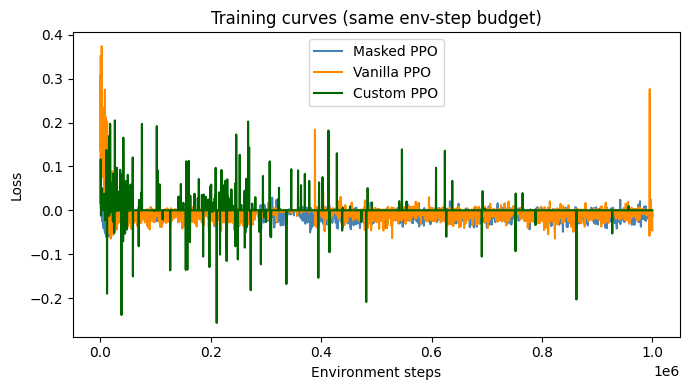

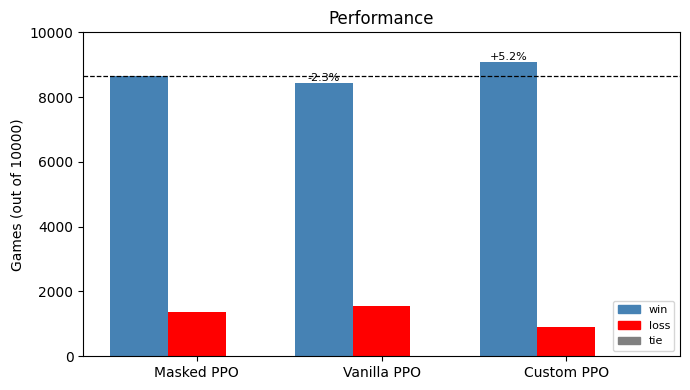

In [14]:
from sb3_contrib import MaskablePPO
from stable_baselines3 import PPO as SB3PPO

print("Evaluating Masked PPO vs random ...")
masked_model = MaskablePPO.load(masked_path)
masked_scores = evaluate_vs_random(connect_four_v3, masked_model, num_games=EVAL_GAMES, seed=SEED)
print(f"  Masked PPO  -- {masked_scores}")

print("Evaluating Vanilla PPO vs random ...")
vanilla_model = SB3PPO.load(vanilla_path)
vanilla_scores = evaluate_vanilla_vs_random(connect_four_v3, vanilla_model, num_games=EVAL_GAMES, seed=SEED)
print(f"  Vanilla PPO -- {vanilla_scores}")

print("Evaluating Custom PPO vs random ...")
custom_scores = evaluate_custom_vs_random(connect_four_v3, custom_ppo.policy, num_games=EVAL_GAMES, seed=SEED)
print(f"  Custom PPO  -- {custom_scores}")

results = {
    "Masked PPO":  masked_scores,
    "Vanilla PPO": vanilla_scores,
    "Custom PPO":  custom_scores,
}

fig1 = plot_training_curves({
    "Masked PPO":  (masked_steps,  masked_losses),
    "Vanilla PPO": (vanilla_steps, vanilla_losses),
    "Custom PPO":  (custom_steps,  custom_losses),
}, colors=COLORS)
plt.show()

fig2 = plot_winrates(results, colors=COLORS, total=EVAL_GAMES)
plt.show()

## Summary

| Variant | Train-time masking | Library | Parallelism |
|---------|-------------------|---------|-------------|
| **Masked PPO** | Yes | `sb3_contrib.MaskablePPO` | `SubprocVecEnv` (N_CORES workers) |
| **Vanilla PPO** | No | `stable_baselines3.PPO` | `SubprocVecEnv` (N_CORES workers) |
| **Custom PPO** | Yes (manual) | Pure PyTorch | `ParallelAECCollector` (N_CORES workers) |

All three share the same parameters: `N_CORES`, `N_STEPS`, `N_EPOCHS`, `LR`, `GAMMA`,
`CLIP_RANGE`, `GAE_LAMBDA`, `ENT_COEF`, `VF_COEF`. Masked and Vanilla PPO collect fixed-length
rollouts via `SubprocVecEnv`, standard SB3 behaviour, so an episode can end mid-rollout.
Custom PPO's `ParallelAECCollector` instead has each worker finish full games before
returning, collecting at least `N_STEPS // N_CORES` steps -- no game is ever cut mid-way.

Device: MPS (Apple Silicon GPU) is used automatically when available for all three variants.